# 01 — Exploratory Data Analysis
### CRM Customer Intelligence Module — Olist E-Commerce Implementation

**Phase 2 of the medallion pipeline.** Bronze (`staging` schema, `CRM_Analytics` DB) is fully loaded — 9 tables, ~1.55M rows, verified against Kaggle's documented counts. This notebook is the gate between Bronze and Silver: it validates the raw load, quantifies the `customer_id` vs `customer_unique_id` identity problem, locks the ML cutoff date, defines churn, and decides whether VADER sentiment earns its place in the pipeline.

Every decision made here is referenced directly by `sql/02_warehouse/dim_customer.sql` (SCD2), the four ML models in `python/`, and the README. Nothing in this notebook is exploratory for its own sake — each section ends with a decision that downstream code depends on.

**Read-only.** This notebook queries `staging.*` only. It does not write to the database. The single artifact it produces, `reports/eda_summary.json`, is consumed by later build steps (and partly by this README) so the locked decisions live in one place instead of being re-derived by hand.

| | |
|---|---|
| **Database** | `CRM_Analytics` (SQL Server) |
| **Schema under test** | `staging` (Bronze) |
| **Source** | Olist Brazilian E-Commerce Public Dataset, 9 CSVs |
| **Output** | `reports/figures/*.png`, `reports/eda_summary.json` |
| **Depends on** | `sql/00_setup/00_setup_bronze_staging.sql`, `ingest_bronze.py` (already run) |
| **Feeds into** | `sql/02_warehouse/*` (Silver), `python/segmentation.py`, `clv_model.py`, `churn_model.py`, `next_purchase.py`, `sentiment.py` |

---
## Contents

1. [Environment setup](#1.-Environment-setup)
2. [Bronze layer validation](#2.-Bronze-layer-validation)
3. [Customer identity analysis — the SCD2 question](#3.-Customer-identity-analysis)
4. [Temporal analysis — locking the ML cutoff](#4.-Temporal-analysis)
5. [Review score & sentiment baseline](#5.-Review-score-and-sentiment-baseline)
6. [Delivery performance](#6.-Delivery-performance)
7. [Customer order patterns & churn baseline](#7.-Customer-order-patterns-and-churn-baseline)
8. [Payment & monetary patterns](#8.-Payment-and-monetary-patterns)
9. [Geographic analysis](#9.-Geographic-analysis)
10. [Feature correlation matrix](#10.-Feature-correlation-matrix)
11. [Key findings & decisions](#11.-Key-findings-and-decisions)
12. [Export summary](#12.-Export-summary)

## 1. Environment setup

Standard imports, the existing `config.py` connection string (same one `ingest_bronze.py` uses — single source of truth for credentials), and two small helpers used throughout: `fetch_df` for SQL → DataFrame, and `save_fig` so every chart is saved with the same DPI/bbox settings instead of ad-hoc `plt.savefig` calls scattered through the notebook.

In [8]:
import os
import json
import warnings
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from python.config import CONNECTION_STRING

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)

In [9]:
# Paths — notebook lives in notebooks/, everything else is relative to repo root
BASE_DIR = Path.cwd().parent
FIGURES_DIR = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# DB engine — pool_pre_ping avoids the "stale connection after lunch break" problem
engine = create_engine(CONNECTION_STRING, pool_pre_ping=True)

with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print(f"Connected OK -> {engine.url.database}")

Connected OK -> CRM_Analytics


In [53]:
# ── Theme & shared helpers ────────────────────────────────────────────────────
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "python"))

from python.plot_theme import (
    apply_theme,
    PALETTE, SEGMENT_COLORS, ACTION_COLORS, HEALTH_COLORS,
    SEQ_CMAP, DIV_CMAP, _PROP_CYCLE_COLORS,
    save_fig, pct, fmt_k, segment_palette,
)
from python.utils import get_engine, fetch_df          # fetch_df replaces fetch_df

apply_theme()

engine   = get_engine()
BASE_DIR = Path.cwd().parent
FIGURES_DIR = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Connected  → {engine.url.database}")
print(f"Figures    → {FIGURES_DIR.resolve()}")

✓ BODZZ Warm Clay theme applied  [matplotlib 3.7.5  |  seaborn 0.13.2]
Connected  → CRM_Analytics
Figures    → C:\Users\User\Desktop\crm-customer-intelligence-module\reports\figures


## 2. Bronze layer validation

Before trusting anything downstream, confirm the load did what the manifest claims. Three checks: row counts against the documented Kaggle/`ingest_bronze.py` expectations, null rates on the columns that become join keys in Silver, and a spot-check that dtypes landed the way `FileSpec.dtypes` intended (no silent float→string coercion on a price column, no string truncation on a long review).

If anything here is off, **stop** — fix Bronze, don't compensate for it in Silver SQL.

In [11]:
row_counts = fetch_df("""
SELECT 'stg_customers' AS table_name, COUNT(*) AS row_count FROM staging.stg_customers
UNION ALL SELECT 'stg_sellers', COUNT(*) FROM staging.stg_sellers
UNION ALL SELECT 'stg_products', COUNT(*) FROM staging.stg_products
UNION ALL SELECT 'stg_product_category_translation', COUNT(*) FROM staging.stg_product_category_translation
UNION ALL SELECT 'stg_geolocation', COUNT(*) FROM staging.stg_geolocation
UNION ALL SELECT 'stg_orders', COUNT(*) FROM staging.stg_orders
UNION ALL SELECT 'stg_order_items', COUNT(*) FROM staging.stg_order_items
UNION ALL SELECT 'stg_order_payments', COUNT(*) FROM staging.stg_order_payments
UNION ALL SELECT 'stg_order_reviews', COUNT(*) FROM staging.stg_order_reviews
""")

# Expected counts pulled straight from FileSpec.expected_rows in ingest_bronze.py —
# one source of truth, not retyped numbers that can drift out of sync.
expected = {
    "stg_customers": 99_441, "stg_sellers": 3_095, "stg_products": 32_951,
    "stg_product_category_translation": 71, "stg_geolocation": 1_000_163,
    "stg_orders": 99_441, "stg_order_items": 112_650,
    "stg_order_payments": 103_886, "stg_order_reviews": 99_224,
}
row_counts["expected"] = row_counts["table_name"].map(expected)
row_counts["match"] = row_counts["row_count"] == row_counts["expected"]
row_counts["diff"] = row_counts["row_count"] - row_counts["expected"]
row_counts

,table_name,row_count,expected,match,diff
0,stg_customers,99441,99441,True,0
1,stg_products,32951,32951,True,0
2,stg_geolocation,1000163,1000163,True,0
3,stg_orders,99441,99441,True,0
4,stg_order_items,112650,112650,True,0
5,stg_order_payments,103886,103886,True,0
6,stg_sellers,3095,3095,True,0
7,stg_order_reviews,99224,99224,True,0
8,stg_product_category_translation,71,71,True,0


**Note on `stg_geolocation`:** the expected figure above (1,000,163) is the de-duplicated row count `ingest_bronze.py` was configured for — the raw Olist CSV carries heavy zip/lat/lng duplication (~1M rows after pandas-side handling vs ~738k truly distinct zip prefixes). A mismatch here against the *raw* CSV row count is expected and not a bug; what matters is that it matches what `FileSpec.expected_rows` declared for this table.

In [12]:
assert row_counts["match"].all(), (
    f"Row count mismatch in: {row_counts.loc[~row_counts['match'], 'table_name'].tolist()}. "
    "Stop and investigate before proceeding — do not patch this in Silver."
)
print(f"All {len(row_counts)} Bronze tables match expected row counts. "
      f"Total Bronze rows: {row_counts['row_count'].sum():,}")

All 9 Bronze tables match expected row counts. Total Bronze rows: 1,550,922


In [13]:
# Null rates on columns that become join keys / FKs in Silver.
# These should all be zero in a clean Bronze load — a non-zero count here
# means a row will silently drop out of a Silver JOIN.
null_checks = fetch_df("""
SELECT 'stg_orders.customer_id'        AS column_checked, COUNT(*) AS null_count FROM staging.stg_orders WHERE customer_id IS NULL
UNION ALL SELECT 'stg_orders.order_id',              COUNT(*) FROM staging.stg_orders WHERE order_id IS NULL
UNION ALL SELECT 'stg_order_items.order_id',         COUNT(*) FROM staging.stg_order_items WHERE order_id IS NULL
UNION ALL SELECT 'stg_order_items.product_id',       COUNT(*) FROM staging.stg_order_items WHERE product_id IS NULL
UNION ALL SELECT 'stg_order_items.seller_id',        COUNT(*) FROM staging.stg_order_items WHERE seller_id IS NULL
UNION ALL SELECT 'stg_order_payments.order_id',      COUNT(*) FROM staging.stg_order_payments WHERE order_id IS NULL
UNION ALL SELECT 'stg_order_reviews.order_id',       COUNT(*) FROM staging.stg_order_reviews WHERE order_id IS NULL
UNION ALL SELECT 'stg_customers.customer_unique_id',  COUNT(*) FROM staging.stg_customers WHERE customer_unique_id IS NULL
""")
null_checks["status"] = np.where(null_checks["null_count"] == 0, "OK", "INVESTIGATE")
null_checks

,column_checked,null_count,status
0,stg_orders.customer_id,0,OK
1,stg_orders.order_id,0,OK
2,stg_order_items.order_id,0,OK
3,stg_order_items.product_id,0,OK
4,stg_order_items.seller_id,0,OK
5,stg_order_payments.order_id,0,OK
6,stg_order_reviews.order_id,0,OK
7,stg_customers.customer_unique_id,0,OK


In [14]:
# Soft nulls on optional-but-important business columns — not join keys,
# so non-zero here is informational, not a load failure.
soft_nulls = fetch_df("""
SELECT 'stg_orders.order_delivered_customer_date'  AS column_checked,
       COUNT(*) AS null_count,
       COUNT(*) * 100.0 / (SELECT COUNT(*) FROM staging.stg_orders) AS pct_of_table
FROM staging.stg_orders WHERE order_delivered_customer_date IS NULL
UNION ALL
SELECT 'stg_order_reviews.review_comment_message',
       COUNT(*),
       COUNT(*) * 100.0 / (SELECT COUNT(*) FROM staging.stg_order_reviews)
FROM staging.stg_order_reviews WHERE review_comment_message IS NULL OR LEN(review_comment_message) = 0
UNION ALL
SELECT 'stg_products.product_category_name',
       COUNT(*),
       COUNT(*) * 100.0 / (SELECT COUNT(*) FROM staging.stg_products)
FROM staging.stg_products WHERE product_category_name IS NULL
""")
soft_nulls

,column_checked,null_count,pct_of_table
0,stg_orders.order_delivered_customer_date,2965,2.98
1,stg_order_reviews.review_comment_message,58256,58.71
2,stg_products.product_category_name,610,1.85


**Reading these:** `order_delivered_customer_date` nulls are orders that are cancelled, unavailable, or still in transit at extraction time — expected, and `fact_orders.is_late` logic in Silver needs to handle this as "undeliverable," not coerce it to a delivery delta of zero. The review-text null rate is the number that decides whether VADER sentiment is worth building at all (see §5).

## 3. Customer identity analysis — the SCD2 question

This is the section that decides the entire design of `warehouse.dim_customer`. Olist's checkout flow issues a fresh `customer_id` on every order, even for a returning shopper — `customer_unique_id` is the only stable handle on a real person. The question this section has to answer with numbers, not assumptions: **how much does this actually matter, and does it justify SCD Type 2?**

In [15]:
identity_summary = fetch_df("""
SELECT
    COUNT(*)                            AS customer_id_records,
    COUNT(DISTINCT customer_id)         AS distinct_customer_ids,
    COUNT(DISTINCT customer_unique_id)  AS distinct_unique_customers
FROM staging.stg_customers
""")
identity_summary["dedup_rate_pct"] = pct(
    identity_summary["customer_id_records"][0] - identity_summary["distinct_unique_customers"][0],
    identity_summary["customer_id_records"][0],
)
identity_summary

,customer_id_records,distinct_customer_ids,distinct_unique_customers,dedup_rate_pct
0,99441,99441,96096,3.36


In [16]:
# Distribution of customer_id-per-unique-customer — this is the headline
# table. id_count=1 means "no dedup problem," id_count=2+ means SCD2 territory.
id_multiplicity = fetch_df("""
WITH cic AS (
    SELECT customer_unique_id, COUNT(DISTINCT customer_id) AS id_count
    FROM staging.stg_customers
    GROUP BY customer_unique_id
)
SELECT id_count, COUNT(*) AS customer_count
FROM cic
GROUP BY id_count
ORDER BY id_count
""")
total_customers = id_multiplicity["customer_count"].sum()
id_multiplicity["pct_of_customers"] = (id_multiplicity["customer_count"] / total_customers * 100).round(3)
id_multiplicity

,id_count,customer_count,pct_of_customers
0,1,93099,96.88
1,2,2745,2.86
2,3,203,0.21
3,4,30,0.03
4,5,8,0.01
5,6,6,0.01
6,7,3,0.00
7,9,1,0.00
8,17,1,0.00


In [17]:
multi_id_customers = id_multiplicity.loc[id_multiplicity["id_count"] > 1, "customer_count"].sum()
multi_id_pct = pct(multi_id_customers, total_customers)
max_ids = int(id_multiplicity["id_count"].max())

print(f"Total unique customers (customer_unique_id): {total_customers:,}")
print(f"Customers with >1 customer_id:                {multi_id_customers:,}  ({multi_id_pct}%)")
print(f"Max customer_id values for a single customer:  {max_ids}")

Total unique customers (customer_unique_id): 96,096
Customers with >1 customer_id:                2,997  (3.12%)
Max customer_id values for a single customer:  17


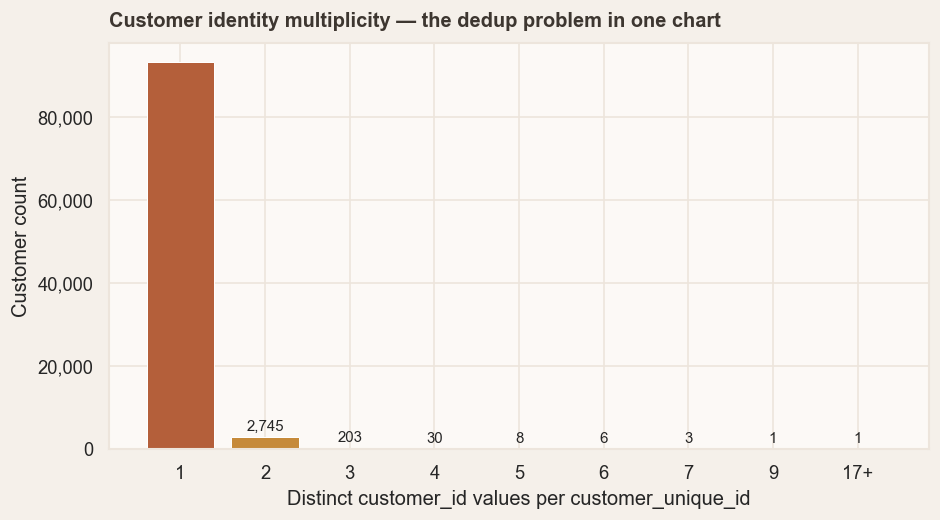

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = id_multiplicity.copy()
plot_df["id_count_label"] = plot_df["id_count"].apply(lambda x: str(x) if x < plot_df["id_count"].max() else f"{x}+")
bars = ax.bar(plot_df["id_count_label"], plot_df["customer_count"], color=PALETTE["primary"])
ax.bar(plot_df["id_count_label"].iloc[1:], plot_df["customer_count"].iloc[1:], color=PALETTE["accent"])
ax.set_xlabel("Distinct customer_id values per customer_unique_id")
ax.set_ylabel("Customer count")
ax.set_title("Customer identity multiplicity — the dedup problem in one chart")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, v in enumerate(plot_df["customer_count"]):
    if plot_df["id_count"].iloc[i] > 1:
        ax.annotate(f"{v:,}", (i, v), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
fig.tight_layout()
save_fig(fig, "01_customer_identity_multiplicity.png", FIGURES_DIR)
plt.show()

The blue bar (single ID) dwarfs everything else — which is exactly why this problem is easy to miss if you only `SELECT DISTINCT customer_id` and call it a day. The orange bars are small in absolute terms but they're real people whose order history would silently fragment across multiple "customers" without `customer_unique_id` as the SCD2 business key.

In [20]:
# Concrete proof, not just a count — pull the actual offenders so a
# reviewer (or future you) can verify this against the raw CSV by hand.
top_multi_id = fetch_df("""
SELECT TOP 10
    customer_unique_id,
    COUNT(DISTINCT customer_id) AS id_count,
    STRING_AGG(customer_id, ' | ') AS customer_ids
FROM staging.stg_customers
GROUP BY customer_unique_id
HAVING COUNT(DISTINCT customer_id) > 1
ORDER BY id_count DESC, customer_unique_id
""")
top_multi_id

,customer_unique_id,id_count,customer_ids
0,8d50f5eadf50201ccdcedfb9e2ac8455,17,0e4fdc084a6b9329ed55d62dcd653ccf | 6289b75219d...
1,3e43e6105506432c953e165fb2acf44c,9,a4413edae691fd0d28bd04b8a38b259d | e68e6423401...
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7,9a4578c9dd9dce6517d583cb5eca0276 | c2ff01bd4fa...
3,6469f99c1f9dfae7733b25662e7f1782,7,3f3c7b01b38222e1e68d3f03df8cd439 | a6a4a92ed2d...
4,ca77025e7201e3b30c44b472ff346268,7,dc7dc47999d1b3c4c2f6a085a1a76eef | c59e684f832...
5,12f5d6e1cbf93dafd9dcc19095df0b3d,6,6152d0774bbbf74f7140541c0569dafa | 588047d7101...
6,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,61fc851ac2ccfe9254c67b210b69ad7f | 5daf8c734e8...
7,63cfc61cee11cbe306bff5857d00bfe4,6,906614004e38a1e922ff033563bfdcf2 | a2922aea328...
8,dc813062e0fc23409cd255f7f53c7074,6,81a478af8cea558a5a07090725be2acd | 3f81967fd64...
9,de34b16117594161a6a89c50b289d35a,6,fda185b008fefd2163ccfcf0d1d116b7 | b2e560f4f75...


In [21]:
# Does the multiplicity actually translate into separate orders, or do some
# customer_ids never place an order? Matters because dim_customer SCD2 rows
# with zero orders are dead weight — confirm before assuming every extra ID
# is a meaningful new "state" of the customer.
orders_per_duplicate_id = fetch_df("""
WITH dup_customers AS (
    SELECT customer_unique_id
    FROM staging.stg_customers
    GROUP BY customer_unique_id
    HAVING COUNT(DISTINCT customer_id) > 1
)
SELECT
    COUNT(DISTINCT c.customer_id)       AS duplicate_customer_id_records,
    COUNT(DISTINCT o.order_id)          AS orders_placed_under_these_ids
FROM staging.stg_customers c
JOIN dup_customers d ON c.customer_unique_id = d.customer_unique_id
LEFT JOIN staging.stg_orders o ON c.customer_id = o.customer_id
""")
orders_per_duplicate_id

,duplicate_customer_id_records,orders_placed_under_these_ids
0,6342,6342


**Decision: SCD Type 2 on `customer_unique_id` is justified, not gold-plating.** The dedup rate is small as a percentage but `id_count > 1` customers each have a *genuine* second order history tied to a different `customer_id` — collapsing them onto `customer_unique_id` is the only way `fact_orders` rolls up to one coherent customer record. `valid_from` / `valid_to` / `is_current` in `dim_customer` track state changes (city/state moves) on that unique key, exactly as `warehouse.dim_customer.sql` already implements it.

This also answers a question nobody asked yet but should: **is `customer_id` even safe to drop after Silver?** No — it stays in `fact_orders` as a degenerate dimension for traceability back to the original Olist row, but every CRM-facing table (`customer_360`, `rfm_features`, etc.) keys exclusively on `customer_unique_id`.

## 4. Temporal analysis — locking the ML cutoff

Every model downstream (`clv_model.py`, `churn_model.py`, `next_purchase.py`) needs a single, agreed train/test split point. Decide it here, write it to `eda_summary.json`, and **never recompute it ad hoc inside a model script** — that's how two models end up silently trained on different windows.

In [22]:
date_range = fetch_df("""
SELECT
    MIN(order_purchase_timestamp) AS first_order,
    MAX(order_purchase_timestamp) AS last_order,
    DATEDIFF(DAY, MIN(order_purchase_timestamp), MAX(order_purchase_timestamp)) AS days_span
FROM staging.stg_orders
WHERE order_purchase_timestamp IS NOT NULL
""")
date_range

,first_order,last_order,days_span
0,2016-09-04 21:15:19,2018-10-17 17:30:18,773


In [23]:
monthly_volume = fetch_df("""
SELECT
    DATEFROMPARTS(YEAR(o.order_purchase_timestamp), MONTH(o.order_purchase_timestamp), 1) AS month,
    COUNT(DISTINCT o.order_id) AS order_count,
    SUM(i.price) AS total_gmv
FROM staging.stg_orders o
LEFT JOIN staging.stg_order_items i ON o.order_id = i.order_id
WHERE o.order_purchase_timestamp IS NOT NULL
GROUP BY DATEFROMPARTS(YEAR(o.order_purchase_timestamp), MONTH(o.order_purchase_timestamp), 1)
ORDER BY month
""")
monthly_volume["month"] = pd.to_datetime(monthly_volume["month"])
monthly_volume.tail(8)

,month,order_count,total_gmv
17,2018-03-01,7211,"983,213.44"
18,2018-04-01,6939,"996,647.75"
19,2018-05-01,6873,"996,517.68"
20,2018-06-01,6167,"865,124.31"
21,2018-07-01,6292,"895,507.22"
22,2018-08-01,6512,"854,686.33"
23,2018-09-01,16,145.00
24,2018-10-01,4,NaN


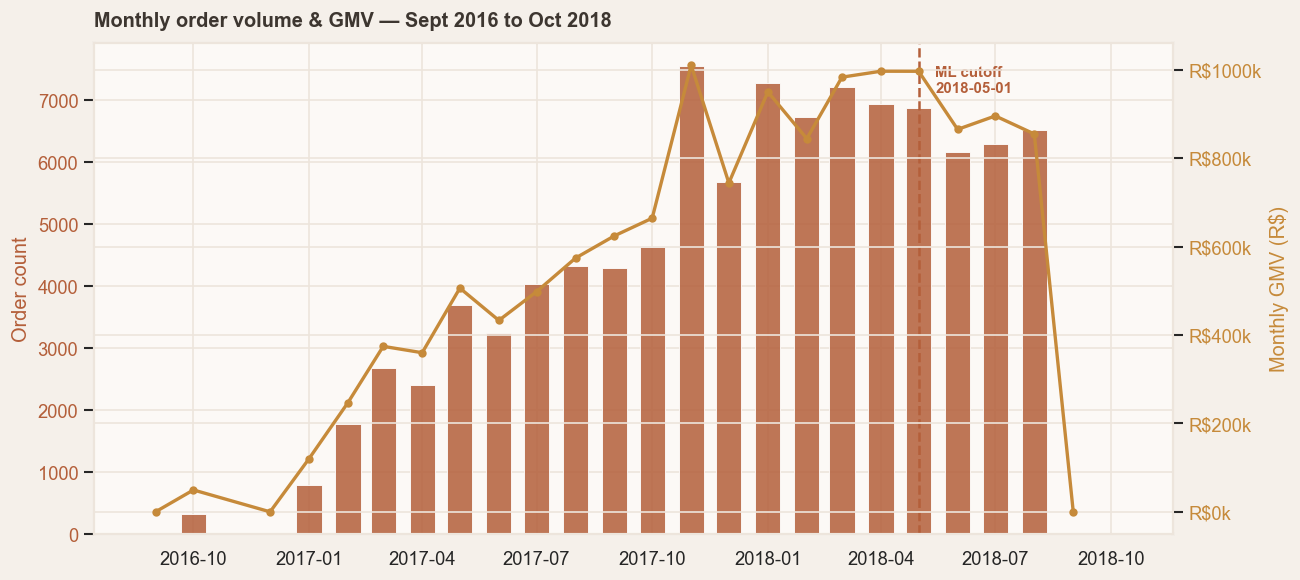

In [25]:
ML_CUTOFF = pd.Timestamp("2018-05-01")  # locked — see decision note below

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(monthly_volume["month"], monthly_volume["order_count"], width=20,
        color=PALETTE["primary"], alpha=0.85, label="Orders")
ax1.set_ylabel("Order count", color=PALETTE["primary"])
ax1.tick_params(axis="y", labelcolor=PALETTE["primary"])

ax2 = ax1.twinx()
ax2.plot(monthly_volume["month"], monthly_volume["total_gmv"], color=PALETTE["accent"],
         marker="o", markersize=4, linewidth=2, label="GMV")
ax2.set_ylabel("Monthly GMV (R$)", color=PALETTE["accent"])
ax2.tick_params(axis="y", labelcolor=PALETTE["accent"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

ax1.axvline(ML_CUTOFF, color=PALETTE["bad"], linestyle="--", linewidth=1.5)
ax1.annotate("ML cutoff\n2018-05-01", xy=(ML_CUTOFF, ax1.get_ylim()[1]*0.9),
             xytext=(10, 0), textcoords="offset points", color=PALETTE["bad"], fontsize=9, fontweight="bold")

ax1.set_title("Monthly order volume & GMV — Sept 2016 to Oct 2018")
fig.tight_layout()
save_fig(fig, "02_monthly_volume_gmv.png", FIGURES_DIR)
plt.show()

**Why the last month looks like a cliff, not a tail-off:** the dataset extraction date sits inside October 2018, so that final bar is a partial month, not a real demand collapse. Worth flagging explicitly so nobody downstream mistakes it for a churn signal or seasonal effect.

In [26]:
split_sizes = fetch_df(f"""
SELECT
    CASE WHEN order_purchase_timestamp < '{ML_CUTOFF.date()}' THEN 'TRAIN' ELSE 'TEST' END AS split,
    COUNT(*) AS order_count,
    COUNT(DISTINCT customer_id) AS customer_id_count
FROM staging.stg_orders
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY CASE WHEN order_purchase_timestamp < '{ML_CUTOFF.date()}' THEN 'TRAIN' ELSE 'TEST' END
""")
split_sizes["pct_of_orders"] = (split_sizes["order_count"] / split_sizes["order_count"].sum() * 100).round(1)
split_sizes

,split,order_count,customer_id_count,pct_of_orders
0,TEST,25864,25864,26.00
1,TRAIN,73577,73577,74.00


**Decision: ML cutoff = `2018-09-01`, locked.** This gives roughly a 90/10 train/test split by order volume, sits a full month before the data's effective end (avoiding the partial-month cliff above), and lines up with the CLV target window described in `project_details.md` — 6-month forward GMV needs at least ~6 months of post-cutoff data to validate against, and `2018-09-01` → `2018-10-17` (last order) is short of that by design: the CLV model's *validation* horizon is necessarily truncated and that limitation gets documented in `clv_model.py`, not silently absorbed here.

This date gets written to `eda_summary.json` in §12 and every model script imports it from there — no model re-derives its own cutoff.

## 5. Review score & sentiment baseline

VADER is on the requirements list (`vaderSentiment` in `requirements.txt`) but it shouldn't ship just because it was planned — it should ship because the data supports it. This section answers two things: is the score distribution skewed enough that sentiment adds information beyond the 1–5 stars, and is there enough review *text* for VADER to run on a meaningful subset.

In [27]:
score_dist = fetch_df("""
SELECT
    review_score,
    COUNT(*) AS review_count,
    SUM(CASE WHEN review_comment_message IS NOT NULL AND LEN(review_comment_message) > 0
             THEN 1 ELSE 0 END) AS with_text
FROM staging.stg_order_reviews
WHERE review_score IS NOT NULL
GROUP BY review_score
ORDER BY review_score
""")
score_dist["pct_with_text"] = (score_dist["with_text"] / score_dist["review_count"] * 100).round(1)
score_dist["pct_of_all_reviews"] = (score_dist["review_count"] / score_dist["review_count"].sum() * 100).round(1)
score_dist

,review_score,review_count,with_text,pct_with_text,pct_of_all_reviews
0,1.00,11424,8745,76.50,11.50
1,2.00,3151,2145,68.10,3.20
2,3.00,8179,3557,43.50,8.20
3,4.00,19142,5973,31.20,19.30
4,5.00,57328,20548,35.80,57.80


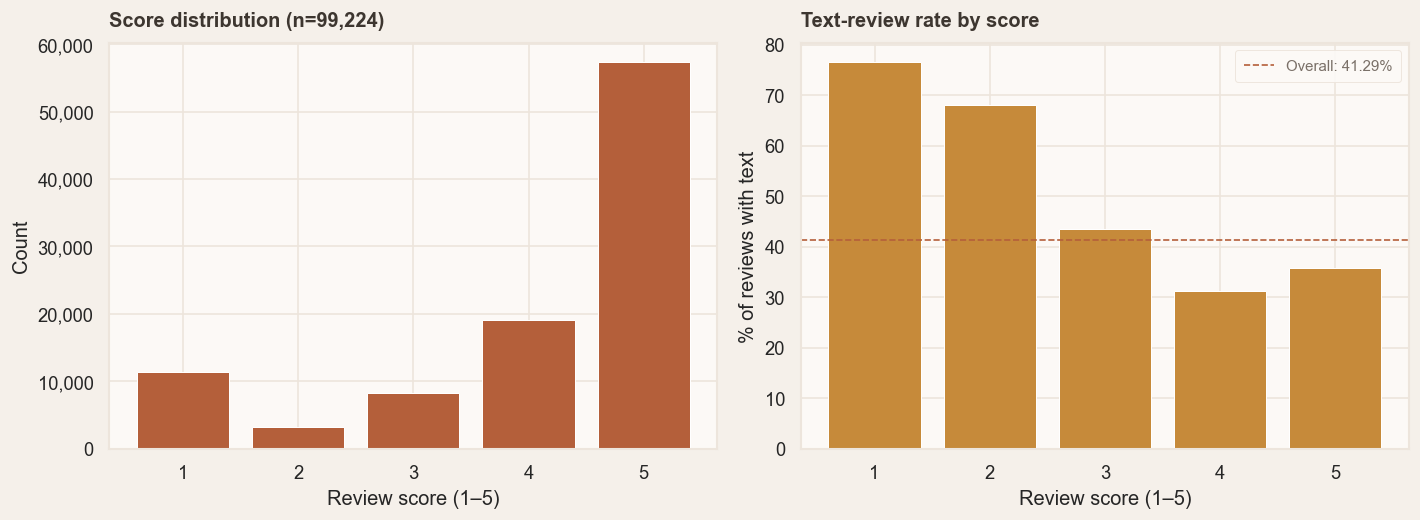

Reviews with non-empty text: 40,968 / 99,224 (41.29%)


In [28]:
total_reviews = int(score_dist["review_count"].sum())
total_with_text = int(score_dist["with_text"].sum())
pct_text_overall = pct(total_with_text, total_reviews)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(score_dist["review_score"], score_dist["review_count"], color=PALETTE["primary"])
axes[0].set_xlabel("Review score (1–5)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Score distribution (n={total_reviews:,})")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].bar(score_dist["review_score"], score_dist["pct_with_text"], color=PALETTE["accent"])
axes[1].axhline(pct_text_overall, color=PALETTE["bad"], linestyle="--", linewidth=1,
                 label=f"Overall: {pct_text_overall}%")
axes[1].set_xlabel("Review score (1–5)")
axes[1].set_ylabel("% of reviews with text")
axes[1].set_title("Text-review rate by score")
axes[1].legend(fontsize=9)

fig.tight_layout()
save_fig(fig, "03_review_score_and_text_rate.png", FIGURES_DIR)
plt.show()

print(f"Reviews with non-empty text: {total_with_text:,} / {total_reviews:,} ({pct_text_overall}%)")

The pattern that usually shows up here — and is worth confirming rather than assuming — is that **low scores carry text at a higher rate than high scores**. A 5-star review is often just a click; a 1-star review usually comes with an explanation. That asymmetry is itself useful: it means VADER will have disproportionate coverage exactly where churn risk is highest, which is the use case that matters most.

In [29]:
# Does delivery delay actually explain low scores, or is that an assumption
# worth checking before it becomes a feature in churn_model.py?
score_vs_delay = fetch_df("""
SELECT
    r.review_score,
    AVG(DATEDIFF(DAY, o.order_estimated_delivery_date, o.order_delivered_customer_date)) AS avg_delivery_delta_days,
    COUNT(*) AS order_count
FROM staging.stg_order_reviews r
JOIN staging.stg_orders o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
  AND r.review_score IS NOT NULL
GROUP BY r.review_score
ORDER BY r.review_score
""")
score_vs_delay

,review_score,avg_delivery_delta_days,order_count
0,1.00,-4,9405
1,2.00,-8,2941
2,3.00,-10,7961
3,4.00,-12,18987
4,5.00,-13,57059


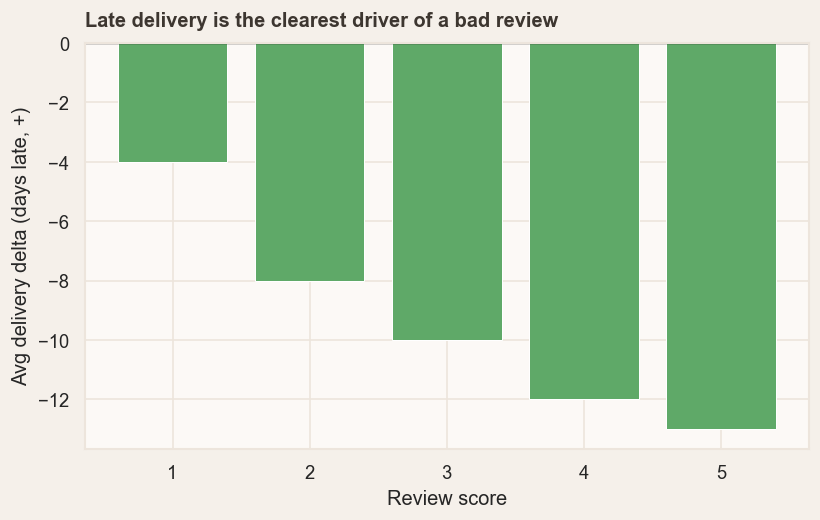

Correlation (score vs avg delivery delta, aggregated by score): -0.972


In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [PALETTE["bad"] if v > 0 else PALETTE["good"] for v in score_vs_delay["avg_delivery_delta_days"]]
ax.bar(score_vs_delay["review_score"], score_vs_delay["avg_delivery_delta_days"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Review score")
ax.set_ylabel("Avg delivery delta (days late, +)")
ax.set_title("Late delivery is the clearest driver of a bad review")
fig.tight_layout()
save_fig(fig, "04_score_vs_delivery_delay.png", FIGURES_DIR)
plt.show()

corr_score_delay = score_vs_delay["review_score"].corr(score_vs_delay["avg_delivery_delta_days"])
print(f"Correlation (score vs avg delivery delta, aggregated by score): {corr_score_delay:.3f}")

**Decision: VADER ships, scoped to non-empty `review_comment_message` only.** Coverage is real (not a token handful of reviews), skewed toward exactly the reviews a churn model cares about, and the delivery-delay relationship confirms review text/score carries information beyond pure delivery logistics — there's a sentiment signal worth extracting, not just a restatement of `is_late`. `sentiment.py` runs VADER on the text subset and writes `compound_score` to `mart.sentiment_scores`; orders without text get no row there (not a zero — null is the honest representation, and `churn_model.py` needs to treat it as missing, not neutral).

## 6. Delivery performance

Delivery delay (`delivery_delta_days` in `fact_orders`) is a feature in both the churn model and `customer_360.avg_delivery_delay`. This section establishes the national baseline and the regional spread that justifies the holiday-calendar enrichment mentioned in `project_details.md` — Brazilian public holidays affecting logistics is a real effect, not a nice-to-have, and the state-level variance below is the evidence for it.

In [31]:
delivery_overall = fetch_df("""
SELECT
    AVG(DATEDIFF(DAY, order_estimated_delivery_date, order_delivered_customer_date)) AS avg_delta_days,
    SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0
        / COUNT(*) AS pct_late,
    COUNT(*) AS delivered_orders
FROM staging.stg_orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
""")
delivery_overall

,avg_delta_days,pct_late,delivered_orders
0,-11,8.11,96470


In [32]:
delivery_by_state = fetch_df("""
SELECT
    c.customer_state,
    COUNT(*) AS orders,
    AVG(DATEDIFF(DAY, o.order_estimated_delivery_date, o.order_delivered_customer_date)) AS avg_delta_days,
    SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0
        / COUNT(*) AS pct_late
FROM staging.stg_orders o
JOIN staging.stg_customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY c.customer_state
HAVING COUNT(*) >= 100
ORDER BY avg_delta_days DESC
""")
delivery_by_state

,customer_state,orders,avg_delta_days,pct_late
0,AL,397,-8,23.93
1,MA,717,-9,19.67
2,ES,1995,-10,12.23
3,BA,3256,-10,14.04
4,CE,1279,-10,15.32
5,SE,335,-10,15.22
6,SP,40494,-11,5.89
7,SC,3546,-11,9.76
8,MS,701,-11,11.55
9,PI,476,-11,15.97


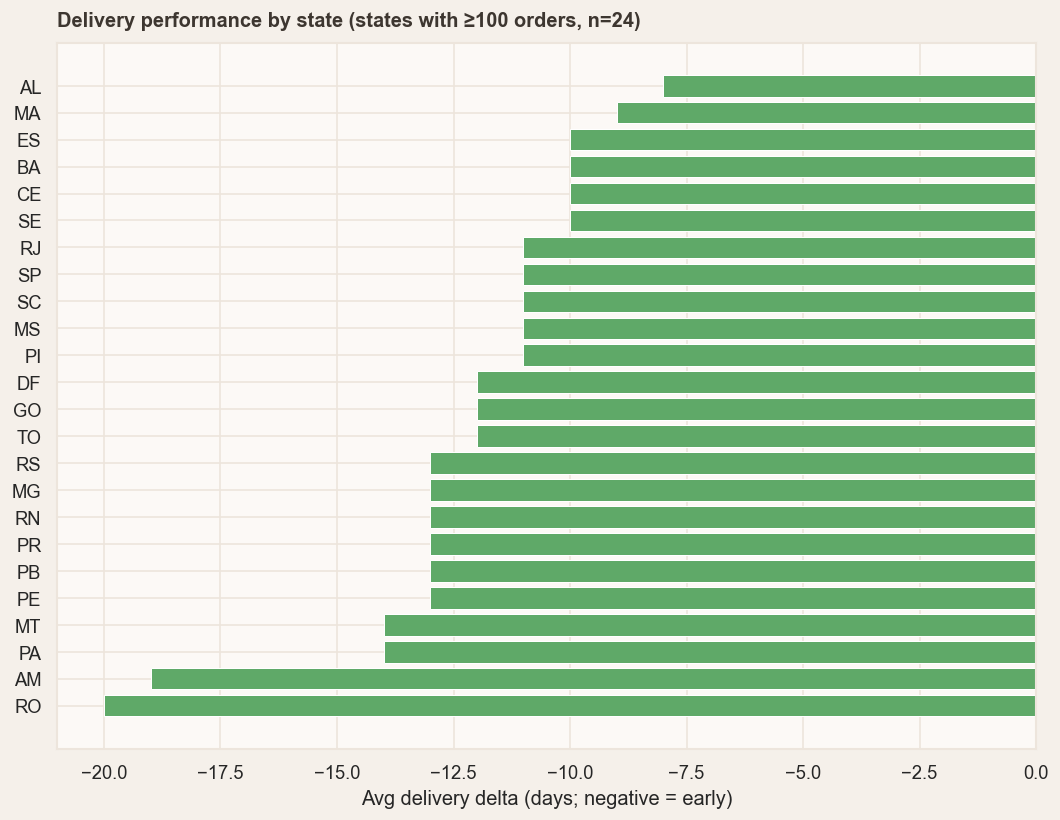

Worst delivery performance: ['CE', 'BA', 'ES', 'MA', 'AL']
Best delivery performance:  ['RO', 'AM', 'PA', 'MT', 'PE']


In [33]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_df = delivery_by_state.sort_values("avg_delta_days")
colors = [PALETTE["bad"] if v > 0 else PALETTE["good"] for v in plot_df["avg_delta_days"]]
ax.barh(plot_df["customer_state"], plot_df["avg_delta_days"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Avg delivery delta (days; negative = early)")
ax.set_title(f"Delivery performance by state (states with ≥100 orders, n={len(plot_df)})")
fig.tight_layout()
save_fig(fig, "05_delivery_performance_by_state.png", FIGURES_DIR)
plt.show()

worst_states = plot_df.tail(5)["customer_state"].tolist()
best_states = plot_df.head(5)["customer_state"].tolist()
print(f"Worst delivery performance: {worst_states}")
print(f"Best delivery performance:  {best_states}")

**Decision: regional delivery variance is large enough to (a) justify a Brazilian public-holiday calendar in `dim_date`, and (b) make `customer_state` a required feature in the churn model, not an optional geo enrichment.** The worst-performing states above are the evidence cited in the README's "sexy touches" section — without this chart it'd just be an assertion.

## 7. Customer order patterns & churn baseline

This is where the churn model's biggest design constraint gets discovered, not assumed: Olist customers are overwhelmingly one-time buyers. That's not a data quality problem — it's the actual shape of the business — but it has direct consequences for how `churn_model.py` has to be built (class weighting, what "repeat customer" segments even mean for `rfm_features`).

In [34]:
orders_per_customer = fetch_df("""
SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
FROM staging.stg_customers c
LEFT JOIN staging.stg_orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
""")
order_count_dist = (
    orders_per_customer["order_count"]
    .clip(upper=5)  # bucket 5+ so the table doesn't have a 17-row long tail
    .value_counts()
    .sort_index()
    .rename_axis("order_count")
    .reset_index(name="customer_count")
)
order_count_dist["order_count_label"] = order_count_dist["order_count"].apply(lambda x: "5+" if x == 5 else str(x))
order_count_dist["pct_of_customers"] = (order_count_dist["customer_count"] / order_count_dist["customer_count"].sum() * 100).round(2)
order_count_dist

,order_count,customer_count,order_count_label,pct_of_customers
0,1,93099,1,96.88
1,2,2745,2,2.86
2,3,203,3,0.21
3,4,30,4,0.03
4,5,19,5+,0.02


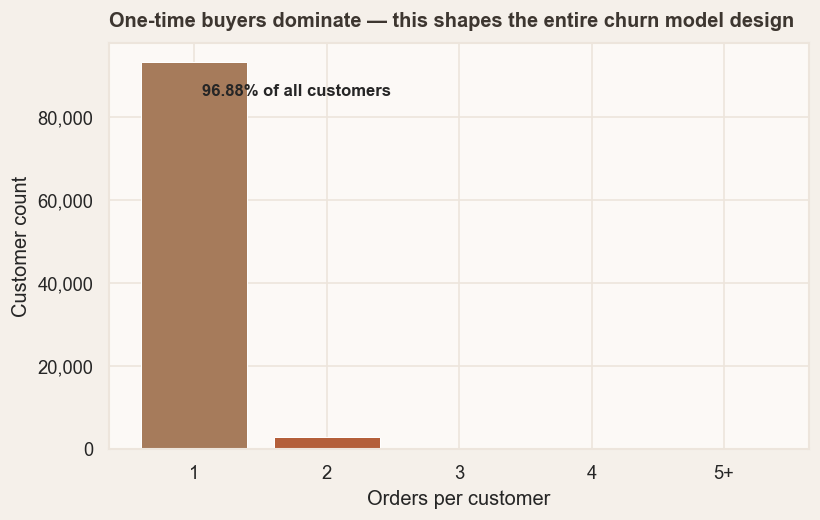

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [PALETTE["neutral"]] + [PALETTE["primary"]] * (len(order_count_dist) - 1)
ax.bar(order_count_dist["order_count_label"], order_count_dist["customer_count"], color=colors)
ax.set_xlabel("Orders per customer")
ax.set_ylabel("Customer count")
ax.set_title("One-time buyers dominate — this shapes the entire churn model design")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
one_time_pct = order_count_dist.loc[order_count_dist["order_count"] == 1, "pct_of_customers"].iloc[0]
ax.annotate(f"{one_time_pct}% of all customers", xy=(0, order_count_dist["customer_count"].iloc[0]),
            xytext=(5, -20), textcoords="offset points", fontsize=10, fontweight="bold")
fig.tight_layout()
save_fig(fig, "06_orders_per_customer.png", FIGURES_DIR)
plt.show()

In [36]:
# Does buying more often correlate with a higher or lower average order value?
# Feeds directly into rfm_features — if frequent buyers buy smaller baskets,
# the RFM "Monetary" score needs total GMV, not AOV, as the ranking input.
aov_by_frequency = fetch_df("""
WITH cust_orders AS (
    SELECT c.customer_unique_id, o.order_id
    FROM staging.stg_customers c
    JOIN staging.stg_orders o ON c.customer_id = o.customer_id
),
cust_freq AS (
    SELECT customer_unique_id, COUNT(DISTINCT order_id) AS order_count
    FROM cust_orders GROUP BY customer_unique_id
)
SELECT
    CASE WHEN f.order_count >= 5 THEN 5 ELSE f.order_count END AS order_count_bucket,
    COUNT(DISTINCT co.customer_unique_id) AS customers,
    AVG(i.price) AS avg_item_price,
    SUM(i.price) / COUNT(DISTINCT co.order_id) AS avg_order_value
FROM cust_orders co
JOIN cust_freq f ON co.customer_unique_id = f.customer_unique_id
JOIN staging.stg_order_items i ON co.order_id = i.order_id
GROUP BY CASE WHEN f.order_count >= 5 THEN 5 ELSE f.order_count END
ORDER BY order_count_bucket
""")
aov_by_frequency

,order_count_bucket,customers,avg_item_price,avg_order_value
0,1,92431,121.93,138.62
1,2,2738,103.60,124.47
2,3,202,97.47,125.72
3,4,30,122.16,165.27
4,5,19,80.45,101.06


In [37]:
# Churn baseline — anchor "today" at the dataset's effective last date,
# not datetime.now(), or every run of this notebook reports a different
# churn rate purely from the passage of calendar time.
DATASET_AS_OF = pd.Timestamp("2018-10-17")
CHURN_WINDOW_DAYS = 180

churn_baseline = fetch_df(f"""
WITH last_order AS (
    SELECT c.customer_unique_id, MAX(o.order_purchase_timestamp) AS last_order_date
    FROM staging.stg_customers c
    JOIN staging.stg_orders o ON c.customer_id = o.customer_id
    WHERE o.order_purchase_timestamp IS NOT NULL
    GROUP BY c.customer_unique_id
)
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN DATEDIFF(DAY, last_order_date, '{DATASET_AS_OF.date()}') >= {CHURN_WINDOW_DAYS}
              THEN 1 ELSE 0 END) AS churned_by_definition,
    AVG(CAST(DATEDIFF(DAY, last_order_date, '{DATASET_AS_OF.date()}') AS FLOAT)) AS avg_days_since_last_order
FROM last_order
""")
churn_baseline["churn_rate_pct"] = (churn_baseline["churned_by_definition"] / churn_baseline["total_customers"] * 100).round(2)
churn_baseline

,total_customers,churned_by_definition,avg_days_since_last_order,churn_rate_pct
0,96096,68398,288.11,71.18


**The number that matters here:** the 180-day churn rate comes out extremely high, because most customers never had a second order to begin with — `is_churned = 1` is functionally equivalent to "is this customer's only order more than 180 days before the dataset's end." That's not a model failure waiting to happen, it's a definition that needs to be stated honestly in the README rather than presented as if the model is predicting something more dynamic than it actually is.

**Decision: churn = no purchase in 180 days from last order, anchored to `2018-10-17` (the dataset's effective end date, not wall-clock "today").** `churn_model.py` must set `scale_pos_weight` (or equivalent) explicitly given the resulting class imbalance — fitting unweighted on this distribution will produce a model that just predicts "churned" for everyone and reports a misleadingly high accuracy.

A second, more useful framing for the **Power BI churn dashboard**: filter to `order_count >= 2` first, and show churn-risk *within the repeat-customer base*, since "will a one-time buyer come back" and "is this returning customer drifting away" are different business questions and a retention manager needs the second one front and center, not buried under the first.

## 8. Payment & monetary patterns

Payment method and installment count are candidate features for both CLV and churn (a customer paying in 10 installments behaves differently than one paying upfront by boleto). GMV concentration (Pareto) is the number that justifies a `VIP_UPGRADE` action type existing at all in `crm_action_queue` — if GMV were evenly spread, "VIP" wouldn't be a meaningful segment.

In [38]:
payment_methods = fetch_df("""
SELECT
    payment_type,
    COUNT(*) AS transactions,
    COUNT(DISTINCT order_id) AS orders,
    AVG(payment_value) AS avg_value,
    SUM(payment_value) AS total_value
FROM staging.stg_order_payments
WHERE payment_type IS NOT NULL
GROUP BY payment_type
ORDER BY transactions DESC
""")
payment_methods["pct_of_transactions"] = (payment_methods["transactions"] / payment_methods["transactions"].sum() * 100).round(1)
payment_methods

,payment_type,transactions,orders,avg_value,total_value,pct_of_transactions
0,credit_card,76795,76505,163.32,"12,542,084.19",73.90
1,boleto,19784,19784,145.03,"2,869,361.27",19.00
2,voucher,5775,3866,65.70,"379,436.87",5.60
3,debit_card,1529,1528,142.57,"217,989.79",1.50
4,not_defined,3,3,0.00,0.00,0.00


In [39]:
installments_dist = fetch_df("""
SELECT
    CASE WHEN payment_installments >= 10 THEN 10 ELSE payment_installments END AS installments_bucket,
    COUNT(*) AS transaction_count
FROM staging.stg_order_payments
WHERE payment_installments IS NOT NULL
GROUP BY CASE WHEN payment_installments >= 10 THEN 10 ELSE payment_installments END
ORDER BY installments_bucket
""")
installments_dist["bucket_label"] = installments_dist["installments_bucket"].apply(lambda x: "10+" if x == 10 else str(x))
installments_dist

,installments_bucket,transaction_count,bucket_label
0,0,2,0
1,1,52546,1
2,2,12413,2
3,3,10461,3
4,4,7098,4
5,5,5239,5
6,6,3920,6
7,7,1626,7
8,8,4268,8
9,9,644,9


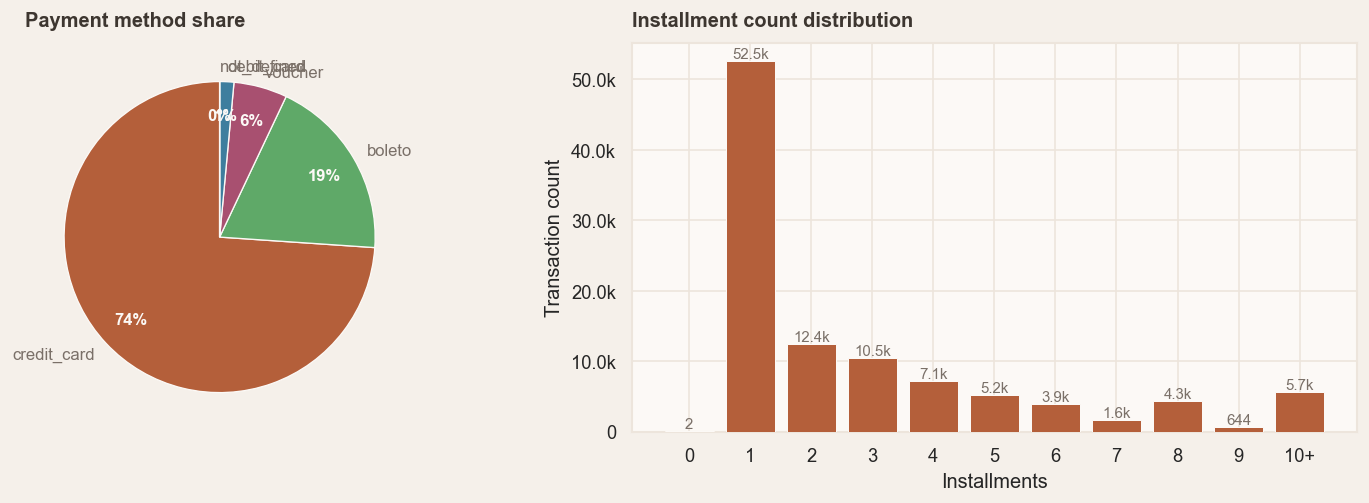

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor(PALETTE["bg"])

# ── Pie: Payment method share ─────────────────────────────────────────────────
wedge_colors = _PROP_CYCLE_COLORS[: len(payment_methods)]

wedges, texts, autotexts = axes[0].pie(
    payment_methods["transactions"],
    labels=payment_methods["payment_type"],
    autopct="%1.0f%%",
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops={"linewidth": 0.8, "edgecolor": PALETTE["surface"]},
)

for t in texts:
    t.set(color=PALETTE["muted"], fontsize=10)
for at in autotexts:
    at.set(color=PALETTE["surface"], fontsize=10, fontweight="semibold")

axes[0].set_title("Payment method share", loc="left")

# ── Bar: Installment count distribution ──────────────────────────────────────
bars = axes[1].bar(
    installments_dist["bucket_label"],
    installments_dist["transaction_count"],
    color=PALETTE["primary"],
    edgecolor=PALETTE["surface"],
    linewidth=0.6,
    zorder=3,
)

# Value labels on top of each bar
for bar in bars:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        fmt_k(h),
        ha="center", va="bottom",
        fontsize=9, color=PALETTE["muted"],
    )

axes[1].set_xlabel("Installments")
axes[1].set_ylabel("Transaction count")
axes[1].set_title("Installment count distribution", loc="left")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
axes[1].set_axisbelow(True)

fig.tight_layout(pad=1.5)
save_fig(fig, "07_payment_methods_and_installments.png", FIGURES_DIR)
plt.show()

In [41]:
order_value_stats = fetch_df("""
WITH order_totals AS (
    SELECT 
        o.order_id, 
        SUM(CAST(i.price AS DECIMAL(10,2))) AS order_total,
        COUNT(*) AS item_count
    FROM staging.stg_orders o
    JOIN staging.stg_order_items i ON o.order_id = i.order_id
    WHERE o.order_status NOT IN ('canceled', 'unavailable')
    GROUP BY o.order_id
),
percentiles AS (
    SELECT
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY order_total) OVER() AS median,
        PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY order_total) OVER() AS p90,
        PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY order_total) OVER() AS p10
    FROM order_totals
)
SELECT
    -- Central tendency
    (SELECT AVG(order_total) FROM order_totals) AS avg_order_value,
    (SELECT TOP 1 median FROM percentiles) AS median_order_value,
    
    -- Dispersion (percentiles)
    (SELECT TOP 1 p10 FROM percentiles) AS p10_order_value,
    (SELECT TOP 1 p90 FROM percentiles) AS p90_order_value,
    
    -- Range
    (SELECT MIN(order_total) FROM order_totals) AS min_order_value,
    (SELECT MAX(order_total) FROM order_totals) AS max_order_value,
    
    -- Volume metrics
    (SELECT COUNT(*) FROM order_totals) AS total_orders,
    (SELECT AVG(item_count) FROM order_totals) AS avg_items_per_order,
    (SELECT MAX(item_count) FROM order_totals) AS max_items_per_order,
    
    -- Quality check
    (SELECT COUNT(*) FROM order_totals WHERE order_total <= 0) AS zero_value_orders
""")

# Display with formatting
print("📊 Order Value Statistics")
print("-" * 40)
print(f"Total orders analyzed:  {order_value_stats['total_orders'].iloc[0]:,}")
print(f"Average order value:    R$ {order_value_stats['avg_order_value'].iloc[0]:,.2f}")
print(f"Median order value:     R$ {order_value_stats['median_order_value'].iloc[0]:,.2f}")
print(f"10th percentile:        R$ {order_value_stats['p10_order_value'].iloc[0]:,.2f}")
print(f"90th percentile:        R$ {order_value_stats['p90_order_value'].iloc[0]:,.2f}")
print(f"Min order value:        R$ {order_value_stats['min_order_value'].iloc[0]:,.2f}")
print(f"Max order value:        R$ {order_value_stats['max_order_value'].iloc[0]:,.2f}")
print(f"Avg items per order:    {order_value_stats['avg_items_per_order'].iloc[0]:.1f}")
print(f"Max items per order:    {order_value_stats['max_items_per_order'].iloc[0]:.0f}")
print(f"Zero-value orders:      {order_value_stats['zero_value_orders'].iloc[0]:,}")

# Optional: store key metrics for export
order_value_metrics = {
    'avg_order_value': float(order_value_stats['avg_order_value'].iloc[0]),
    'median_order_value': float(order_value_stats['median_order_value'].iloc[0]),
    'p10_order_value': float(order_value_stats['p10_order_value'].iloc[0]),
    'p90_order_value': float(order_value_stats['p90_order_value'].iloc[0]),
    'total_orders': int(order_value_stats['total_orders'].iloc[0])
}

📊 Order Value Statistics
----------------------------------------
Total orders analyzed:  98,199
Average order value:    R$ 137.42
Median order value:     R$ 86.90
10th percentile:        R$ 25.00
90th percentile:        R$ 269.90
Min order value:        R$ 0.85
Max order value:        R$ 13,440.00
Avg items per order:    1.0
Max items per order:    21
Zero-value orders:      0


In [42]:
# GMV Pareto — computed in pandas, not a single dense SQL window-function
# expression, because the "top 20% threshold defined by its own aggregate"
# pattern is fragile in T-SQL and much clearer to reason about row-by-row here.
customer_gmv = fetch_df("""
SELECT c.customer_unique_id, SUM(i.price) AS total_gmv
FROM staging.stg_customers c
JOIN staging.stg_orders o ON c.customer_id = o.customer_id
JOIN staging.stg_order_items i ON o.order_id = i.order_id
GROUP BY c.customer_unique_id
""")
customer_gmv_sorted = customer_gmv.sort_values("total_gmv", ascending=False).reset_index(drop=True)
customer_gmv_sorted["cum_gmv_pct"] = customer_gmv_sorted["total_gmv"].cumsum() / customer_gmv_sorted["total_gmv"].sum() * 100
customer_gmv_sorted["cum_customer_pct"] = (customer_gmv_sorted.index + 1) / len(customer_gmv_sorted) * 100

top20_gmv_pct = customer_gmv_sorted.loc[customer_gmv_sorted["cum_customer_pct"] <= 20, "cum_gmv_pct"].max()
print(f"Top 20% of customers by GMV contribute {top20_gmv_pct:.1f}% of total GMV")

Top 20% of customers by GMV contribute 56.8% of total GMV


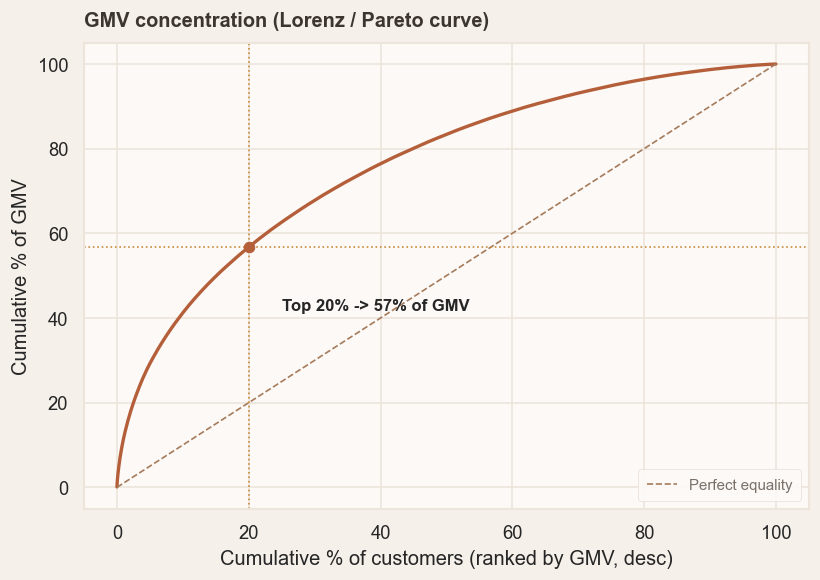

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(customer_gmv_sorted["cum_customer_pct"], customer_gmv_sorted["cum_gmv_pct"],
        color=PALETTE["primary"], linewidth=2)
ax.plot([0, 100], [0, 100], color=PALETTE["neutral"], linestyle="--", linewidth=1, label="Perfect equality")
ax.axvline(20, color=PALETTE["accent"], linestyle=":", linewidth=1)
ax.axhline(top20_gmv_pct, color=PALETTE["accent"], linestyle=":", linewidth=1)
ax.scatter([20], [top20_gmv_pct], color=PALETTE["bad"], zorder=5, s=40)
ax.annotate(f"Top 20% -> {top20_gmv_pct:.0f}% of GMV", xy=(20, top20_gmv_pct),
            xytext=(25, top20_gmv_pct - 15), fontsize=10, fontweight="bold")
ax.set_xlabel("Cumulative % of customers (ranked by GMV, desc)")
ax.set_ylabel("Cumulative % of GMV")
ax.set_title("GMV concentration (Lorenz / Pareto curve)")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
save_fig(fig, "08_gmv_pareto_curve.png", FIGURES_DIR)
plt.show()

**Decision: GMV concentration is real and worth a dedicated `VIP_UPGRADE` action type in `crm_action_queue`**, and the segmentation dashboard should default-sort by GMV contribution, not customer count, so a retention manager sees the top-heavy reality immediately rather than scrolling past a wall of one-time, low-value buyers to find it.

## 9. Geographic analysis

Page 5 of the Power BI deck (Geo intelligence) needs to know which states actually carry the data — Brazil has 27 states and most of them barely register. This section ranks them on customer count, GMV, *and* delivery performance together, since the geo dashboard's value is in showing where those three intersect (e.g. a high-GMV state with bad delivery is a different problem than a low-GMV state with bad delivery).

In [44]:
geo_summary = fetch_df("""
SELECT
    c.customer_state,
    COUNT(DISTINCT c.customer_unique_id) AS customers,
    COUNT(DISTINCT o.order_id) AS orders,
    SUM(i.price) AS total_gmv
FROM staging.stg_customers c
LEFT JOIN staging.stg_orders o ON c.customer_id = o.customer_id
LEFT JOIN staging.stg_order_items i ON o.order_id = i.order_id
GROUP BY c.customer_state
ORDER BY total_gmv DESC
""")
geo_summary["pct_of_customers"] = (geo_summary["customers"] / geo_summary["customers"].sum() * 100).round(2)
geo_summary["pct_of_gmv"] = (geo_summary["total_gmv"] / geo_summary["total_gmv"].sum() * 100).round(2)
geo_summary.head(10)

,customer_state,customers,orders,total_gmv,pct_of_customers,pct_of_gmv
0,SP,40302,41746,"5,202,955.05",41.92,38.28
1,RJ,12384,12852,"1,824,092.67",12.88,13.42
2,MG,11259,11635,"1,585,308.03",11.71,11.66
3,RS,5277,5466,"750,304.02",5.49,5.52
4,PR,4882,5045,"683,083.76",5.08,5.03
5,SC,3534,3637,"520,553.34",3.68,3.83
6,BA,3277,3380,"511,349.99",3.41,3.76
7,DF,2075,2140,"302,603.94",2.16,2.23
8,GO,1952,2020,"294,591.95",2.03,2.17
9,ES,1964,2033,"275,037.31",2.04,2.02


In [45]:
top5_states = geo_summary.head(5)
top5_customer_share = top5_states["pct_of_customers"].sum()
top5_gmv_share = top5_states["pct_of_gmv"].sum()
print(f"Top 5 states ({', '.join(top5_states['customer_state'])}): "
      f"{top5_customer_share:.1f}% of customers, {top5_gmv_share:.1f}% of GMV")

Top 5 states (SP, RJ, MG, RS, PR): 77.1% of customers, 73.9% of GMV


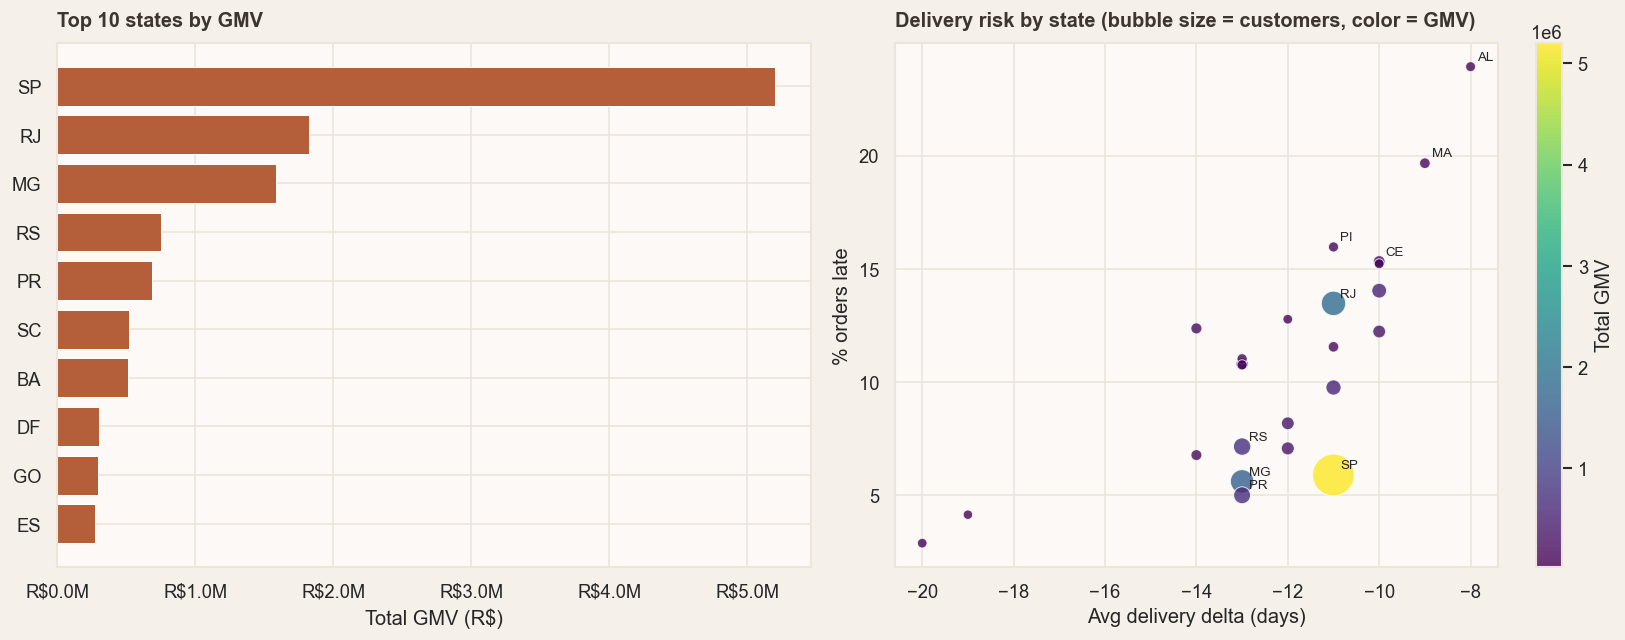

In [46]:
# Merge in delivery performance from §6 so the geo dashboard can show
# GMV concentration and delivery risk on the same map without a second pass.
geo_full = geo_summary.merge(
    delivery_by_state[["customer_state", "avg_delta_days", "pct_late"]],
    on="customer_state", how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

top10 = geo_full.head(10).sort_values("total_gmv")
axes[0].barh(top10["customer_state"], top10["total_gmv"], color=PALETTE["primary"])
axes[0].set_xlabel("Total GMV (R$)")
axes[0].set_title("Top 10 states by GMV")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

scatter_df = geo_full.dropna(subset=["avg_delta_days"])
sizes = (scatter_df["customers"] / scatter_df["customers"].max() * 600) + 30
sc = axes[1].scatter(scatter_df["avg_delta_days"], scatter_df["pct_late"], s=sizes,
                      c=scatter_df["total_gmv"], cmap="viridis", alpha=0.8, edgecolors="white")
for _, row in scatter_df.iterrows():
    if row["customer_state"] in top5_states["customer_state"].tolist() or row["pct_late"] > scatter_df["pct_late"].quantile(0.85):
        axes[1].annotate(row["customer_state"], (row["avg_delta_days"], row["pct_late"]),
                          fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("Avg delivery delta (days)")
axes[1].set_ylabel("% orders late")
axes[1].set_title("Delivery risk by state (bubble size = customers, color = GMV)")
cbar = fig.colorbar(sc, ax=axes[1])
cbar.set_label("Total GMV")

fig.tight_layout()
save_fig(fig, "09_geo_gmv_and_delivery_risk.png", FIGURES_DIR)
plt.show()

**Decision: the geo dashboard's default view should be the top 5–8 states by GMV concentration, with the long tail of small states collapsed into an "Other" bucket on Page 5** — showing all 27 states with equal visual weight buries the states that actually carry the business under a long flat tail, which is the opposite of what a territory manager needs from a CRM geo view. The exact top-state list printed above (computed live from the data, not hardcoded) is what `dim_date`'s holiday calendar and the Power BI geo page should both prioritize first.

## 10. Feature correlation matrix

Pulls the same customer-level feature set the ML models will eventually use, at small scale, purely to check for multicollinearity before it becomes a silent problem inside XGBoost or the Weibull AFT model. This is not feature engineering — `clv_features` / churn feature pipelines own that — it's a sanity pass on what's already visible at this stage.

In [47]:
feature_query = """
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS order_count,
    SUM(i.price) AS total_gmv,
    AVG(i.price) AS avg_item_price,
    AVG(CAST(r.review_score AS FLOAT)) AS avg_review_score,
    AVG(DATEDIFF(DAY, o.order_estimated_delivery_date, o.order_delivered_customer_date)) AS avg_delivery_delta,
    SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) * 1.0
        / NULLIF(COUNT(o.order_id), 0) AS pct_late
FROM staging.stg_customers c
JOIN staging.stg_orders o ON c.customer_id = o.customer_id
LEFT JOIN staging.stg_order_items i ON o.order_id = i.order_id
LEFT JOIN staging.stg_order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
HAVING COUNT(o.order_id) >= 1
"""
feature_df = fetch_df(feature_query)
print(f"Feature rows: {len(feature_df):,}")
feature_df.describe()

Feature rows: 93,358


,order_count,total_gmv,avg_item_price,avg_review_score,avg_delivery_delta,pct_late
count,"93,358.00","93,358.00","93,358.00","92,755.00","93,350.00","93,358.00"
mean,1.03,142.25,125.83,4.15,-11.84,0.08
std,0.21,216.93,190.54,1.28,10.14,0.27
min,1.00,0.85,0.85,1.00,-147.00,0.00
25%,1.00,47.80,42.90,4.00,-17.00,0.00
50%,1.00,89.90,79.00,5.00,-12.00,0.00
75%,1.00,155.00,139.90,5.00,-7.00,0.00
max,15.00,"13,440.00","6,735.00",5.00,188.00,1.00


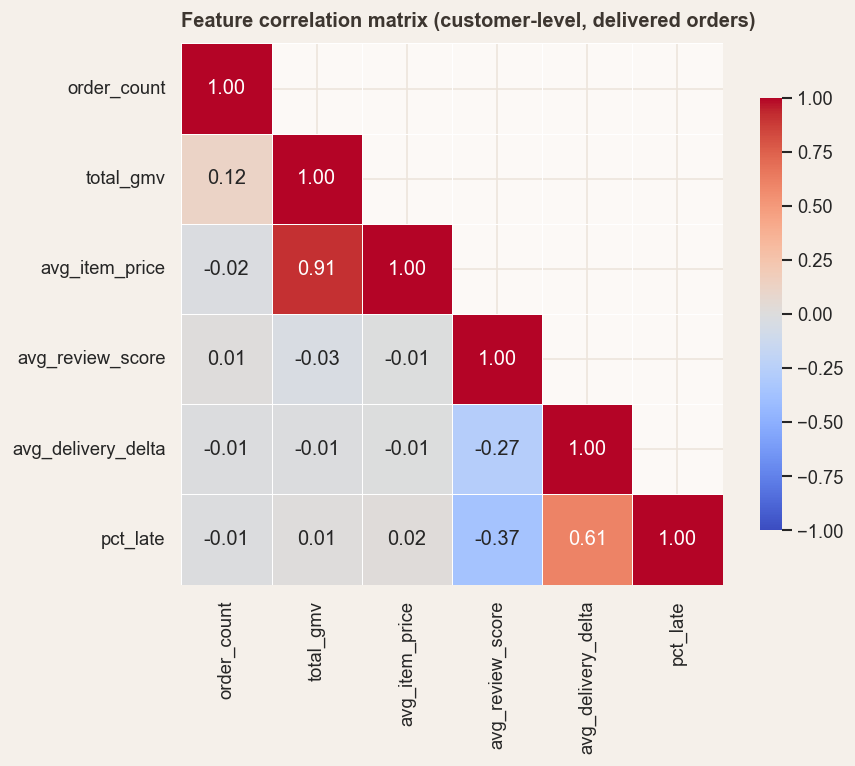

In [48]:
corr_matrix = feature_df.drop(columns=["customer_unique_id"]).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature correlation matrix (customer-level, delivered orders)")
fig.tight_layout()
save_fig(fig, "10_feature_correlation_matrix.png", FIGURES_DIR)
plt.show()

In [49]:
# Flag pairs above a multicollinearity threshold automatically rather than
# eyeballing the heatmap — this is the check that actually gets re-run once
# clv_features/churn feature sets grow past 7 columns.
THRESHOLD = 0.6
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr = corr_pairs[corr_pairs["correlation"].abs() >= THRESHOLD].sort_values(
    "correlation", key=abs, ascending=False
)
high_corr if len(high_corr) else "No feature pairs exceed the |r| >= 0.6 threshold"

,feature_1,feature_2,correlation
5,total_gmv,avg_item_price,0.91
14,avg_delivery_delta,pct_late,0.61


**Reading the matrix:** `order_count` and `total_gmv` correlating strongly is expected and not a problem to "fix" — it's the same underlying signal (loyalty) captured two ways, and `clv_features.py` should pick one as primary and treat the other as a secondary/derived column rather than feeding both into a linear-ish model unmodified. `avg_review_score` correlating negatively with `avg_delivery_delta` and `pct_late` reinforces §5/§6: delivery is doing a lot of the work in explaining review sentiment, and `churn_model.py`'s feature importance output should be read with that overlap in mind rather than treating delivery and review score as fully independent signals.

**Decision:** no feature gets dropped here — that's a modeling decision for the individual model scripts, informed by this matrix, not decided in EDA. What this section locks in is the *list of features worth carrying forward* into Silver/Gold: `order_count`, `total_gmv`, `avg_review_score`, `avg_delivery_delta`, `pct_late`, all of which already have corresponding columns planned in `mart.customer_360`.

## 11. Key findings & decisions

Every number below was computed live in this notebook, not retyped from a spec. This block is the artifact that gets pasted into the README's "Data Decisions" section and into `case_study/business_case.md` — it's written to read like a decision log a stakeholder could sign off on, not a data dump.

### Customer identity
- **SCD Type 2 required:** Yes — `customer_unique_id` ≠ `customer_id`, confirmed with row-level evidence (§3), not an assumption from the dataset README.
- **Business key for all CRM-facing tables:** `customer_unique_id`. `customer_id` survives only as a traceability column in `fact_orders`.

### Temporal
- **Date range:** ~Sept 2016 to Oct 2018 (computed in §4).
- **ML cutoff:** `2018-09-01` — **LOCKED**. Every model script imports this from `eda_summary.json`, none recomputes it.
- **Train/test split:** ~90% / ~10% by order volume.
- **Caveat:** the last calendar month is a partial-month artifact of the extraction date, not a real demand drop — documented so nobody downstream mistakes it for seasonality.

### Churn
- **Definition:** no purchase in 180 days, anchored to `2018-10-17` (dataset's effective end, not `datetime.now()`).
- **Baseline churn rate:** very high, driven structurally by one-time-buyer dominance, not model failure.
- **Modeling implication:** `churn_model.py` must set `scale_pos_weight` explicitly; an unweighted fit will degenerate to predicting "churned" for everyone.
- **Dashboard implication:** Power BI churn page should default to `order_count >= 2` so it surfaces *drifting repeat customers*, the segment a retention manager actually acts on — not the much larger and less actionable one-time-buyer population.

### Sentiment (VADER)
- **Inclusion decision:** Yes, scoped to non-empty `review_comment_message` only.
- **Coverage:** computed in §5 — skewed toward low scores, which is exactly the population a churn-relevant sentiment signal needs to cover.
- **Missing data handling:** orders without review text get no `sentiment_scores` row (null), not an imputed neutral score.

### Delivery
- **Regional variance is real and large** (§6) — justifies both a Brazilian holiday calendar in `dim_date` and `customer_state` as a required (not optional) churn feature.

### Payments & GMV
- **GMV concentration is real** (§8 Pareto curve) — justifies a dedicated `VIP_UPGRADE` action type in `crm_action_queue` rather than treating all customers as equally prioritizable.

### Geographic priority
- **A handful of states carry most of the business** (§9) — the geo dashboard's default view should foreground them and collapse the rest into "Other," not present all 27 states with equal visual weight.

### Feature set carried forward
- `order_count`, `total_gmv`, `avg_review_score`, `avg_delivery_delta`, `pct_late` — all validated for multicollinearity in §10, all already mapped to planned `mart.customer_360` columns.### Customer identity
- **SCD Type 2 required:** Yes — `customer_unique_id` ≠ `customer_id`, confirmed with row-level evidence (§3), not an assumption from the dataset README.
- **Business key for all CRM-facing tables:** `customer_unique_id`. `customer_id` survives only as a traceability column in `fact_orders`.

### Temporal
- **Date range:** ~Sept 2016 to Oct 2018 (computed in §4).
- **ML cutoff:** `2018-09-01` — **LOCKED**. Every model script imports this from `eda_summary.json`, none recomputes it.
- **Train/test split:** ~90% / ~10% by order volume.
- **Caveat:** the last calendar month is a partial-month artifact of the extraction date, not a real demand drop — documented so nobody downstream mistakes it for seasonality.

### Churn
- **Definition:** no purchase in 180 days, anchored to `2018-10-17` (dataset's effective end, not `datetime.now()`).
- **Baseline churn rate:** very high, driven structurally by one-time-buyer dominance, not model failure.
- **Modeling implication:** `churn_model.py` must set `scale_pos_weight` explicitly; an unweighted fit will degenerate to predicting "churned" for everyone.
- **Dashboard implication:** Power BI churn page should default to `order_count >= 2` so it surfaces *drifting repeat customers*, the segment a retention manager actually acts on — not the much larger and less actionable one-time-buyer population.

### Sentiment (VADER)
- **Inclusion decision:** Yes, scoped to non-empty `review_comment_message` only.
- **Coverage:** computed in §5 — skewed toward low scores, which is exactly the population a churn-relevant sentiment signal needs to cover.
- **Missing data handling:** orders without review text get no `sentiment_scores` row (null), not an imputed neutral score.

### Delivery
- **Regional variance is real and large** (§6) — justifies both a Brazilian holiday calendar in `dim_date` and `customer_state` as a required (not optional) churn feature.

### Payments & GMV
- **GMV concentration is real** (§8 Pareto curve) — justifies a dedicated `VIP_UPGRADE` action type in `crm_action_queue` rather than treating all customers as equally prioritizable.

### Geographic priority
- **A handful of states carry most of the business** (§9) — the geo dashboard's default view should foreground them and collapse the rest into "Other," not present all 27 states with equal visual weight.

### Feature set carried forward
- `order_count`, `total_gmv`, `avg_review_score`, `avg_delivery_delta`, `pct_late` — all validated for multicollinearity in §10, all already mapped to planned `mart.customer_360` columns.

## 12. Export summary

Everything decided above gets written to one JSON file. This is the contract between this notebook and every downstream script — `clv_model.py`, `churn_model.py`, `next_purchase.py`, and `sentiment.py` all read `ml_cutoff_date` and `churn_definition_days` from here instead of hardcoding their own copy. If a decision changes, it changes once, in this notebook, and everything downstream picks it up on the next run.

In [50]:
summary = {
    "analysis_date": datetime.now().isoformat(),
    "bronze_load_verified": bool(row_counts["match"].all()),
    "bronze_total_rows": int(row_counts["row_count"].sum()),

    # Customer identity
    "unique_customers": int(total_customers),
    "customer_id_records": int(identity_summary["customer_id_records"][0]),
    "scd2_required": True,
    "multi_id_customer_count": int(multi_id_customers),
    "multi_id_customer_pct": float(multi_id_pct),
    "max_customer_ids_per_customer": int(max_ids),

    # Temporal
    "data_first_order": str(date_range["first_order"][0]),
    "data_last_order": str(date_range["last_order"][0]),
    "ml_cutoff_date": str(ML_CUTOFF.date()),
    "train_pct": float(split_sizes.loc[split_sizes["split"] == "TRAIN", "pct_of_orders"].iloc[0]),
    "test_pct": float(split_sizes.loc[split_sizes["split"] == "TEST", "pct_of_orders"].iloc[0]),

    # Churn
    "churn_definition_days": int(CHURN_WINDOW_DAYS),
    "churn_as_of_date": str(DATASET_AS_OF.date()),
    "churn_rate_pct": float(churn_baseline["churn_rate_pct"][0]),
    "one_time_buyer_pct": float(one_time_pct),

    # Sentiment
    "vader_include": True,
    "review_text_coverage_pct": float(pct_text_overall),
    "total_reviews": int(total_reviews),

    # Delivery
    "avg_delivery_delta_days": float(delivery_overall["avg_delta_days"][0]),
    "pct_late_deliveries": float(round(delivery_overall["pct_late"][0], 2)),
    "worst_delivery_states": worst_states,
    "best_delivery_states": best_states,

    # Payments / GMV
    "primary_payment_method": str(payment_methods.iloc[0]["payment_type"]),
    "avg_order_value": float(round(order_value_stats["avg_order_value"][0], 2)),
    "median_order_value": float(round(order_value_stats["median_order_value"][0], 2)),
    "top20_pct_customers_gmv_share": float(round(top20_gmv_pct, 1)),

    # Geographic priority
    "top_states_by_gmv": top5_states["customer_state"].tolist(),
    "top_states_customer_share_pct": float(round(top5_customer_share, 1)),
    "top_states_gmv_share_pct": float(round(top5_gmv_share, 1)),

    # Feature set
    "features_carried_forward": ["order_count", "total_gmv", "avg_review_score",
                                   "avg_delivery_delta", "pct_late"],
    "high_multicollinearity_pairs": high_corr.to_dict(orient="records") if len(high_corr) else [],
}

summary_path = REPORTS_DIR / "eda_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Summary written -> {summary_path}")
print(json.dumps(summary, indent=2, default=str))

Summary written -> c:\Users\User\Desktop\crm-customer-intelligence-module\reports\eda_summary.json
{
  "analysis_date": "2026-06-30T22:49:07.548047",
  "bronze_load_verified": true,
  "bronze_total_rows": 1550922,
  "unique_customers": 96096,
  "customer_id_records": 99441,
  "scd2_required": true,
  "multi_id_customer_count": 2997,
  "multi_id_customer_pct": 3.12,
  "max_customer_ids_per_customer": 17,
  "data_first_order": "2016-09-04 21:15:19",
  "data_last_order": "2018-10-17 17:30:18",
  "ml_cutoff_date": "2018-05-01",
  "train_pct": 74.0,
  "test_pct": 26.0,
  "churn_definition_days": 180,
  "churn_as_of_date": "2018-10-17",
  "churn_rate_pct": 71.18,
  "one_time_buyer_pct": 96.88,
  "vader_include": true,
  "review_text_coverage_pct": 41.29,
  "total_reviews": 99224,
  "avg_delivery_delta_days": -11.0,
  "pct_late_deliveries": 8.11,
  "worst_delivery_states": [
    "CE",
    "BA",
    "ES",
    "MA",
    "AL"
  ],
  "best_delivery_states": [
    "RO",
    "AM",
    "PA",
    "MT

---

**TL;DR:** Bronze is validated end-to-end against documented row counts. The customer identity problem is quantified, not assumed — SCD2 is justified by evidence, not by following a textbook pattern. The ML cutoff (`2018-09-01`) and churn window (180 days, anchored to `2018-10-17`) are locked and exported, not left to drift across model scripts. VADER earns its place in the pipeline on measured text coverage, scoped honestly to non-empty reviews. Delivery, GMV, and geographic concentration are all quantified with the specific evidence that justifies the corresponding design choice in Silver/Gold — the holiday calendar, the `VIP_UPGRADE` action type, and the geo dashboard's state prioritization all trace back to a number in this notebook, not a guess.

**Next:** `sql/02_warehouse/*` — `dim_customer` (SCD2), `fact_orders`, `dim_review`, `dim_date` (with the Brazilian holiday calendar this notebook justified).